In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime, timedelta
from skforecast.plot import calculate_lag_autocorrelation

In [7]:
#Modeling and Forecasting
import skforecast
import lightgbm
import sklearn
from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
"""
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from skforecast.plot import plot_residuals
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 8})
"""

### Load Raw Data

In [15]:
"""
#EIA DATA
#df = pd.read_csv("../data/raw/tempload.csv", index_col = "date", parse_dates = True)
#need to drop duplicates
#idk why the extract script is buggy
#chain it all togther
# df isn't defined yet in the df["date"] call so we need to use pipe
df = (pd.read_csv("../data/raw/tempload.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'
"""

In [10]:
#GS Data
#df = pd.read_csv("../data/raw/tempload.csv", index_col = "date", parse_dates = True)
#need to drop duplicates
#idk why the extract script is buggy
#chain it all togther
# df isn't defined yet in the df["date"] call so we need to use pipe
df = (pd.read_csv("../data/raw/gstempload.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
#set frequency after checking for duplicates or missing values
#df.index.freq = 'h'

In [12]:
#should have 26304 rows
# missing 7 rows
df.shape

(26297, 2)

### Check Series is Complete and Fill

In [13]:
#check mising hours, check that series is complete
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h")
missing = full_index.difference(df.index)
print(f"Missing hours: {len(missing)}")
print(missing)

Missing hours: 7
DatetimeIndex(['2023-03-12 08:00:00', '2023-05-24 02:00:00',
               '2023-05-24 03:00:00', '2024-03-10 08:00:00',
               '2024-04-14 03:00:00', '2024-04-14 04:00:00',
               '2024-11-03 06:00:00'],
              dtype='datetime64[us]', freq=None)


In [16]:
#interpolate missing hours
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h")
df = df.reindex(full_index)
df.index.name = "date"
df["Demand"] = df["Demand"].interpolate(method="time")
df["Temperature"] = df["Temperature"].interpolate(method="time")
print(df.shape)  # should now be 26,304

(26304, 2)


In [19]:
#check df frequency
df.index.freq

<Hour>

In [47]:
#create a copy of the data frame before we start modifying it
df0 = df.copy()

### Check and Fill NA Values and Outliers

In [17]:
#check for rows with missing values
df[df.isnull().any(axis = 1)]

,Demand,Temperature
date,,


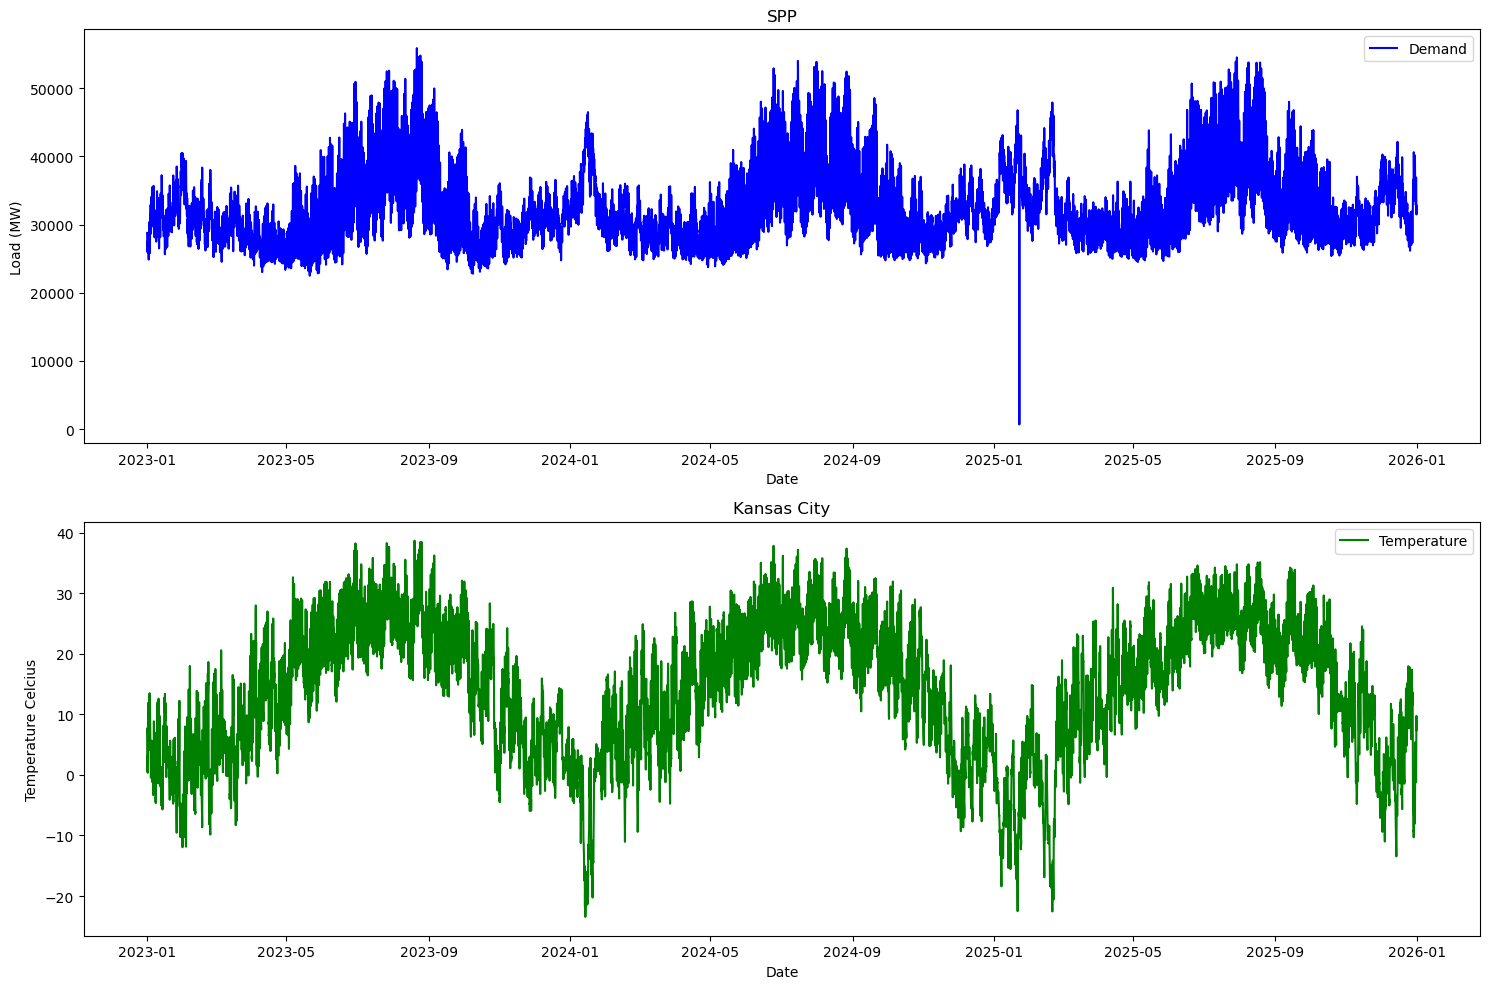

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(df.index, df["Demand"], label="Demand", color="blue")
axes[1].plot(df.index, df["Temperature"], label="Temperature", color = "green")

axes[0].set_title("SPP")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Load (MW)")
axes[0].legend()

axes[1].set_title("Kansas City")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Temperature Celcius")
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
#clearly there is an outlier in the load data collection that we need to replace
df["Demand"] = (df["Demand"]
    .mask(df["Demand"] == df["Demand"].min())
    .ffill()
)

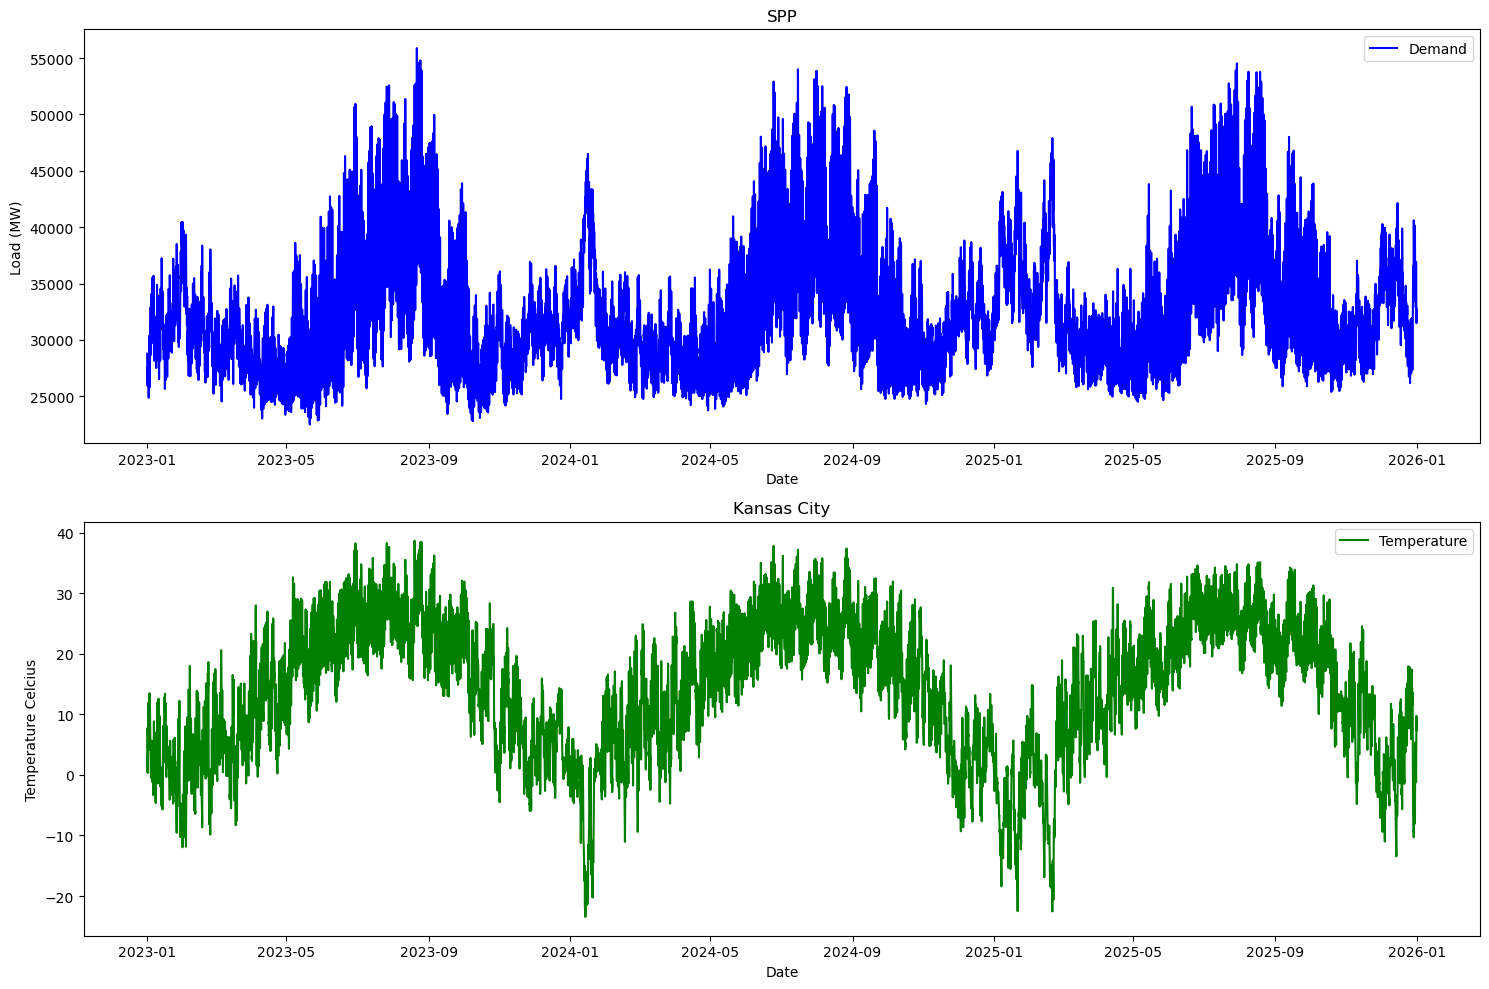

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(df.index, df["Demand"], label="Demand", color="blue")
axes[1].plot(df.index, df["Temperature"], label="Temperature", color = "green")

axes[0].set_title("SPP")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Load (MW)")
axes[0].legend()

axes[1].set_title("Kansas City")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Temperature Celcius")
axes[1].legend()

plt.tight_layout()
plt.show()

graph a one week span to see check load and temperature alignment, we would expect load to peak slightly after peaks/changes in temperature

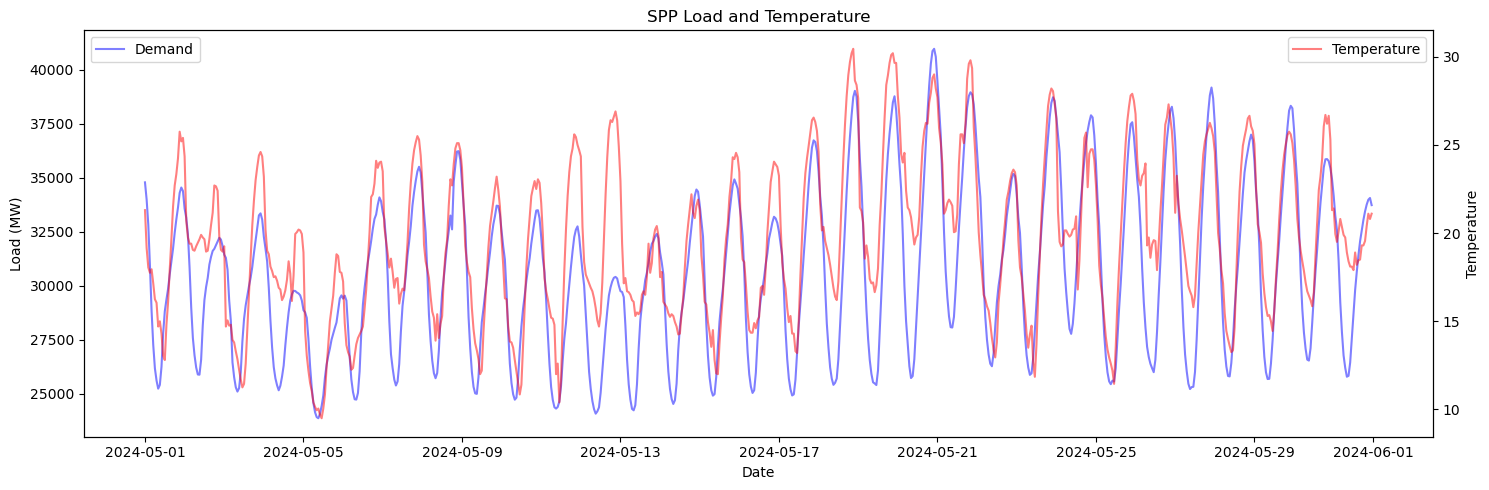

In [28]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df.loc["2024-05"].index, df.loc["2024-05"]["Demand"], label="Demand", color="blue", alpha=0.5)
#ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend(loc="upper left")

ax2 = ax.twinx()
ax2.plot(df.loc["2024-05"].index, df.loc["2024-05"]["Temperature"], label="Temperature", color="red", alpha=0.5)
ax2.set_ylabel("Temperature")
ax2.legend(loc="upper right")

plt.title("SPP Load and Temperature")
plt.tight_layout()
plt.show()

### Finding Data Anomalies

#### Heat Map of Weeks

In [29]:
# Reshape data into hour x date matrix
heatmap_data = df.copy()
heatmap_data["date_only"] = heatmap_data.index.date
heatmap_data["hour"] = heatmap_data.index.hour

pivot = heatmap_data.pivot(index="date_only", columns="hour", values="Demand")

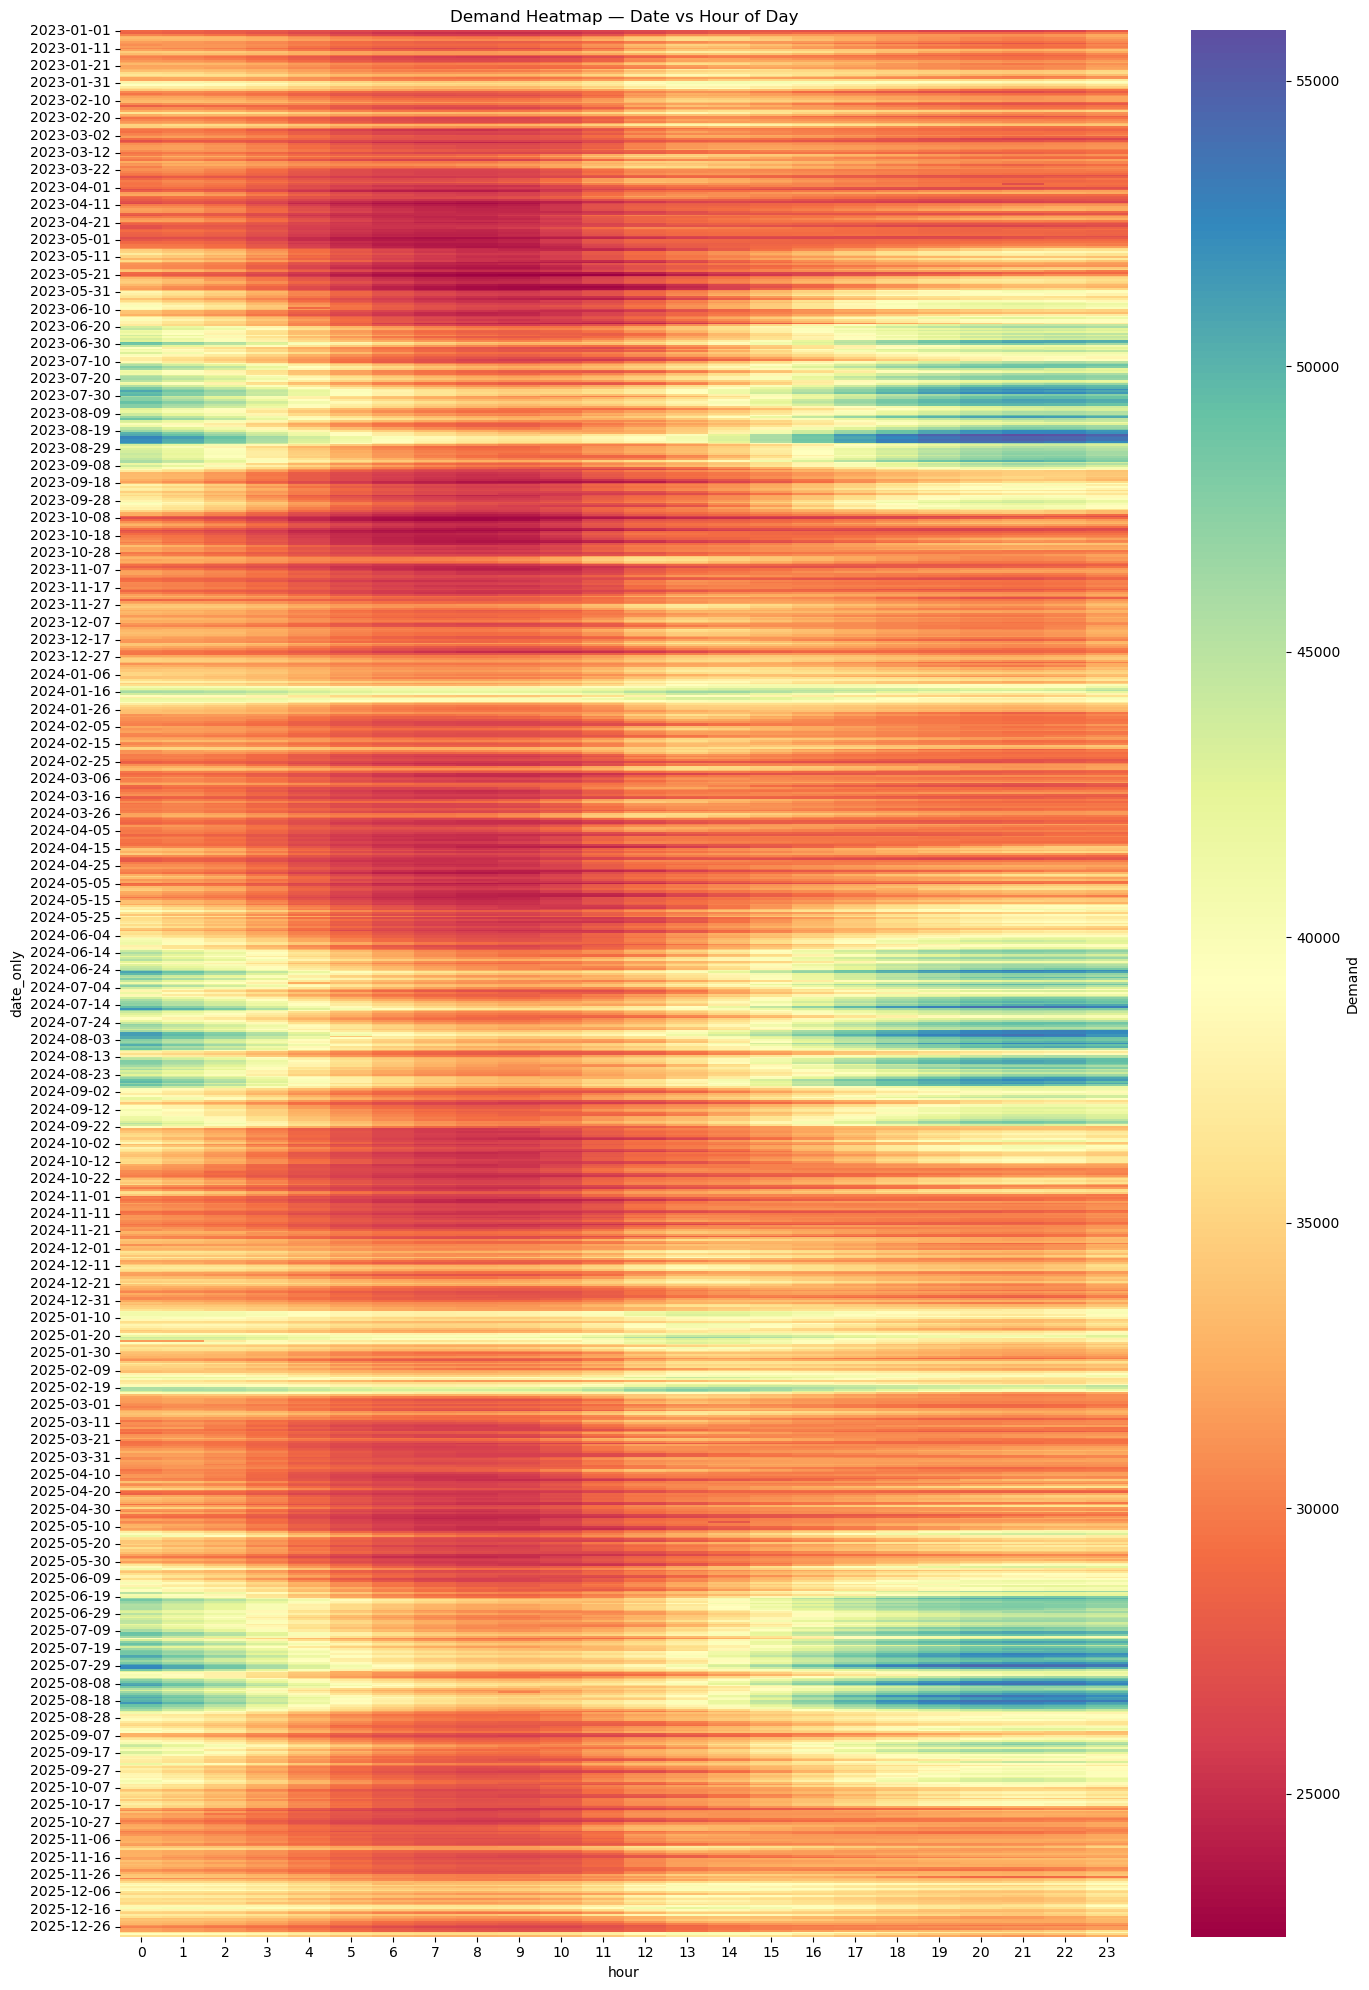

In [30]:
fig, ax = plt.subplots(figsize=(14, 20))
sns.heatmap(pivot, cmap="Spectral", ax=ax, cbar_kws={"label": "Demand"})
ax.set_title("Demand Heatmap — Date vs Hour of Day")
plt.tight_layout()
plt.show()

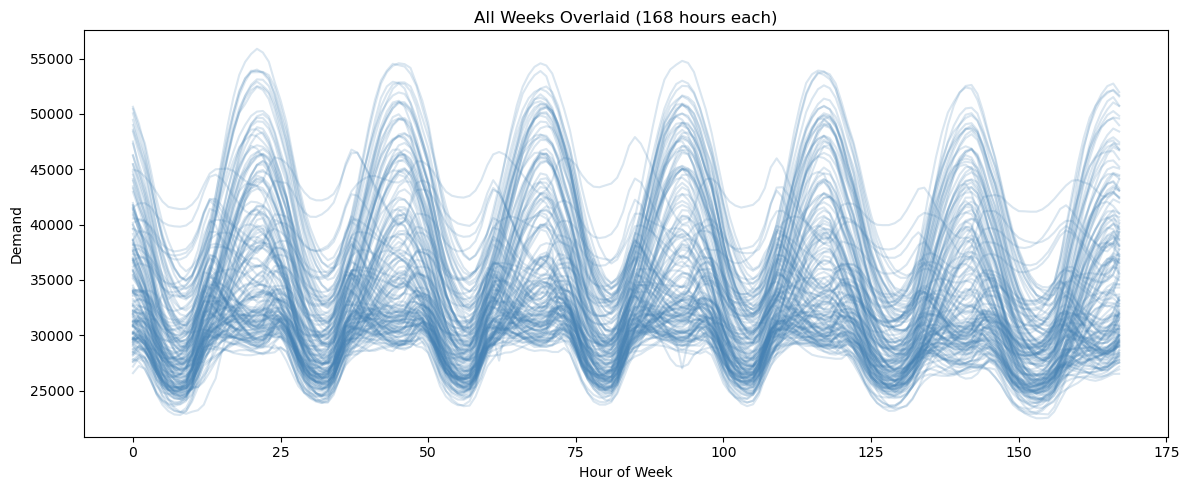

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))

for year_week, group in df.groupby([df.index.year, df.index.isocalendar().week]):
    if len(group) == 168:  # full week only
        ax.plot(range(168), group["Demand"].values, alpha=0.2, color="steelblue")

ax.set_title("All Weeks Overlaid (168 hours each)")
ax.set_xlabel("Hour of Week")
ax.set_ylabel("Demand")
plt.tight_layout()
plt.show()

nothing looks like an outlier in the weeks overlay or the heat map. No flat spots are wild spikes

### Check Summary Stats by Week

In [23]:
weekly_stats = (df
    .groupby([df.index.year, df.index.isocalendar().week])["Demand"]
    .agg(["std", "min", "max", "count"])
    .reset_index()
    .rename(columns={"date": "year", "level_1": "week"})
)

In [24]:
# Add start/end timestamps for each week
week_bounds = (df
    .groupby([df.index.year, df.index.isocalendar().week])
    .apply(lambda g: pd.Series({"start": g.index.min(), "end": g.index.max()}))
    .reset_index()
    .rename(columns={"date": "year", "level_1": "week"})
)

weekly_stats = weekly_stats.merge(week_bounds, on=["year", "week"])
weekly_stats["range"] = weekly_stats["max"] - weekly_stats["min"]

In [ ]:
#let's look at the variance by week
weekly_stats["std"].describe()

In [ ]:
# Sort by lowest variance to find flattest weeks
# if a "typical" week has a std of around 1,700 than anything well below that is worth looking at
suspicious_weeks = weekly_stats.sort_values("std").head(10)
suspicious_weeks.sort_values("start")

#### Flat Runs (Only Run if the data looks like it has flat runs this was an EIA data issue not gridstatus)

In [27]:
"""
#find weeks that have repeated values within the week but might not be completely bad
#find partial flat runs where there is a long stretch without a difference in demand value
# Flag any hour where demand barely changed from the previous hour
dfFlat = df.copy()
dfFlat["diff"] = dfFlat["Demand"].diff().abs()

# Find runs of near-zero change (adjust threshold based on your typical hour-to-hour variation)
flat_threshold = 5  # MW — tune this based on your data's normal volatility
dfFlat["is_flat"] = dfFlat["diff"] < flat_threshold

# Find consecutive flat runs of meaningful length
dfFlat["flat_group"] = (dfFlat["is_flat"] != dfFlat["is_flat"].shift()).cumsum()
flat_runs = (dfFlat[dfFlat["is_flat"]]
    .groupby("flat_group")
    .agg(start=("Demand", lambda x: x.index[0]),
         end=("Demand", lambda x: x.index[-1]),
         length=("Demand", "size"))
)
"""

In [ ]:
"""
# Only keep runs of meaningful length (e.g. 3+ consecutive flat hours)
suspicious_runs = flat_runs[flat_runs["length"] >= 3].sort_values("start", ascending=True)
suspicious_runs.sort_values("length", ascending = False)
"""

### Fixing the flat runs
- a week is 168 hours so anything that is close to that should be discarded
- making a judgement call, that a full week is probably too long of a stretch to impute
- Step 1: drop data after 2025-5-19
    - end data will be 2025-05-18 23:00:00
- Step 2: we will impute the values using the data from +-2 weeks
    - this should help preserve seasonal/daily patterns more than a linear imputation  

In [31]:
"""
def flag_suspicious_runs_as_nan(df, suspicious_runs, column="Demand"):
    df = df.copy()
    for _, row in suspicious_runs.iterrows():
        df.loc[row["start"]:row["end"], column] = np.nan
    return df
"""

In [32]:
"""
def seasonal_fill(df, start, end, lookback_weeks=2):
    for ts in pd.date_range(start, end, freq="h"):
        similar_hours = [ts - pd.Timedelta(weeks=w) for w in range(1, lookback_weeks+1)] + \
                         [ts + pd.Timedelta(weeks=w) for w in range(1, lookback_weeks+1)]
        valid = [df.loc[t, "Demand"] for t in similar_hours if t in df.index and not pd.isna(df.loc[t, "Demand"])]
        if valid:
            df.loc[ts, "Demand"] = np.mean(valid)
    return df
"""

In [35]:
"""
#replace flat runs with NaN
df = flag_suspicious_runs_as_nan(df, suspicious_runs)
date_ranges = list(zip(suspicious_runs["start"], suspicious_runs["end"]))
#date_ranges
for start,end in date_ranges:
    df = seasonal_fill(df, start, end)
"""

graph the weekly overlay chart again to see if we have eliminated all the bad weeks 

The data looks better but that are still some large jumps and spikes in the data and an odd flat week at the end

let's test the residuals on a simple 24 lagged model

### Checking base model residuals

In [32]:
# Create forecaster
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )
forecaster.fit(y=df['Demand'], store_in_sample_residuals=True)

In [33]:
residuals = pd.Series(forecaster.in_sample_residuals_)

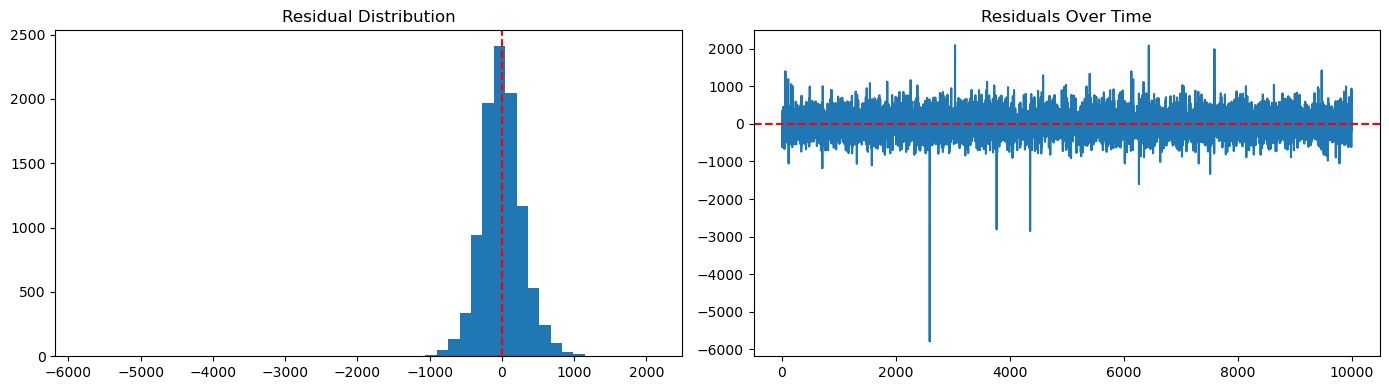

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(residuals, bins=50)
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Residuals over index (order they were generated)
axes[1].plot(residuals.values)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()

There are some big outliers we can investigate more later, the residuals do look normally distributed so the data doesn't appear biased

### Save the cleaned data set

In [36]:
#let's write the clean df to csv
df.to_csv("../data/raw/gsloadtemp_clean.csv", index=True)

### Train Val Test Split
- Train: 2023-01-01 to 2024-06-30 (18 months)
- Validation: 2024-07-01 to 2024-12-31 (6 months)
- Test: 2025-01-01 to 2025-12-31 (12 months)

In [38]:
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"

VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"

TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"

In [40]:
data = df.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Graphs

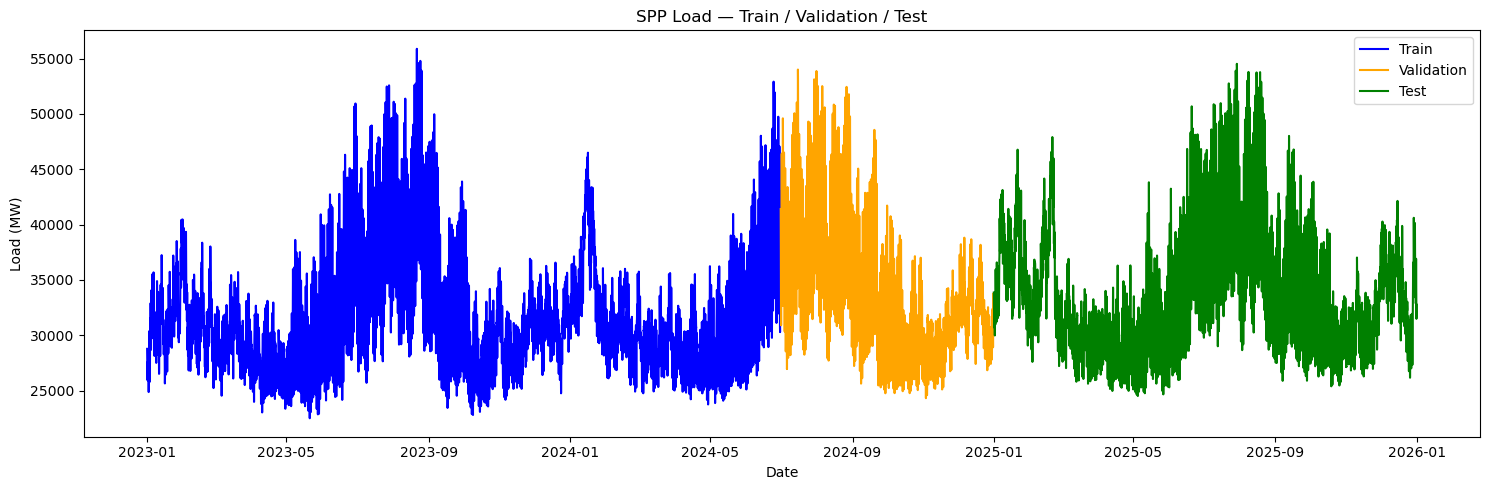

In [41]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_train.index, data_train["Demand"], label="Train", color="blue")
ax.plot(data_val.index, data_val["Demand"], label="Validation", color="orange")
ax.plot(data_test.index, data_test["Demand"], label="Test", color="green")

ax.set_title("SPP Load — Train / Validation / Test")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

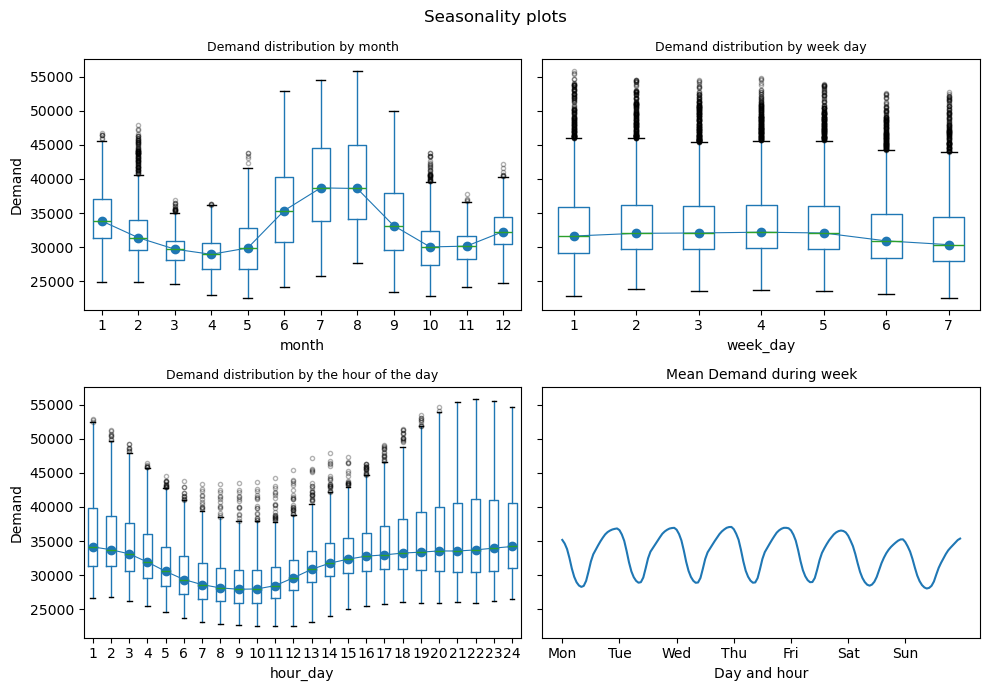

In [42]:
# Annual, weekly and daily seasonality
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=True)
axs = axs.ravel()

# Demand distribution by month
data['month'] = data.index.month
data.boxplot(column='Demand', by='month', ax=axs[0], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('month')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[0])
axs[0].set_ylabel('Demand')
axs[0].set_title('Demand distribution by month', fontsize=9)

# Demand distribution by week day
data['week_day'] = data.index.day_of_week + 1
data.boxplot(column='Demand', by='week_day', ax=axs[1], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('week_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[1])
axs[1].set_ylabel('Demand')
axs[1].set_title('Demand distribution by week day', fontsize=9)

# Demand distribution by the hour of the day
data['hour_day'] = data.index.hour + 1
data.boxplot(column='Demand', by='hour_day', ax=axs[2], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('hour_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[2])
axs[2].set_ylabel('Demand')
axs[2].set_title('Demand distribution by the hour of the day', fontsize=9)

# Demand distribution by week day and hour of the day
mean_day_hour = data.groupby(["week_day", "hour_day"])["Demand"].mean()
mean_day_hour.plot(ax=axs[3])
axs[3].set(
    title       = "Mean Demand during week",
    xticks      = [i * 24 for i in range(7)],
    xticklabels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel      = "Day and hour",
    ylabel      = "Number of Demand"
)
axs[3].title.set_size(10)

fig.suptitle("Seasonality plots", fontsize=12)
fig.tight_layout()

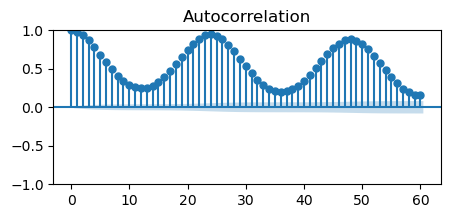

In [43]:
# Autocorrelation plot
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(data['Demand'], ax=ax, lags=60, fft=True)
plt.show()

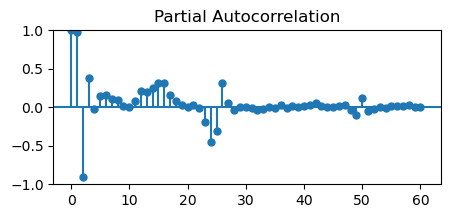

In [44]:
# Partial autocorrelation plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(5, 2))
plot_pacf(data['Demand'], ax=ax, lags=60, method='burg')
plt.show()

In [46]:
# Top 10 lags with the highest absolute partial autocorrelation
# ==============================================================================
calculate_lag_autocorrelation(
    data        = data['Demand'],
    n_lags      = 170,
    sort_by     = "partial_autocorrelation_abs",
    acf_kwargs  = {'fft': True},
    pacf_kwargs = {'method': 'burg'}
).head(10)

,lag,partial_autocorrelation_abs,partial_autocorrelation,autocorrelation_abs,autocorrelation
0,1,0.983489,0.983489,0.983479,0.983479
1,2,0.911756,-0.911756,0.937370,0.937370
2,24,0.450234,-0.450234,0.946199,0.946199
3,3,0.374013,0.374013,0.867807,0.867807
4,26,0.315898,0.315898,0.881647,0.881647
5,15,0.312061,0.312061,0.328828,0.328828
6,16,0.311668,0.311668,0.392968,0.392968
7,25,0.307931,-0.307931,0.928124,0.928124
8,14,0.245293,0.245293,0.282370,0.282370
9,12,0.212747,0.212747,0.246814,0.246814
